## Telco customer churn prediction

### Step 1. import libraries

In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

### Step 2. Load Dataset

In [28]:
# load excel file
file_path = (r"C:\Users\saini\OneDrive\Documents\python\ml churn project\Telco_customer_churn.xlsx" )

df = pd.read_excel(file_path)

### Step 3. Dataset Information

In [ ]:
# rowsand columns
print(df.shape)

# dataset columns
print(df.columns)

# data types
print(df.info())

# missing values 
print(df.isnull().sum())

(7043, 33)
Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7

### Step 4. Data Cleaning

In [36]:
# remove un necessary columns
remove_columns = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Churn Label', 'Churn Score', 'CLTV','Churn Reason']

# drop columns
df= df.drop(columns = remove_columns)

In [38]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [42]:
df = df.drop(columns = 'Longitude')

In [43]:
# fill missing values
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].mean())

print(df.head(5))

   Gender Senior Citizen Partner Dependents  Tenure Months Phone Service  \
0    Male             No      No         No              2           Yes   
1  Female             No      No        Yes              2           Yes   
2  Female             No      No        Yes              8           Yes   
3  Female             No     Yes        Yes             28           Yes   
4    Male             No      No        Yes             49           Yes   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support Streaming TV Streaming Movies  \
0                No           No           No               No   
1       

### Step 5. Convert categorical data into numbers

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   int64  
 1   Senior Citizen     7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   int64  
 7   Internet Service   7043 non-null   int64  
 8   Online Security    7043 non-null   int64  
 9   Online Backup      7043 non-null   int64  
 10  Device Protection  7043 non-null   int64  
 11  Tech Support       7043 non-null   int64  
 12  Streaming TV       7043 non-null   int64  
 13  Streaming Movies   7043 non-null   int64  
 14  Contract           7043 non-null   int64  
 15  Paperless Billing  7043 non-null   int64  
 16  Payment Method     7043 

In [44]:
# create label encoder
le = LabelEncoder()

# convert object columns
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print(df.head(5))

   Gender  Senior Citizen  Partner  Dependents  Tenure Months  Phone Service  \
0       1               0        0           0              2              1   
1       0               0        0           1              2              1   
2       0               0        0           1              8              1   
3       0               0        1           1             28              1   
4       1               0        0           1             49              1   

   Multiple Lines  Internet Service  Online Security  Online Backup  \
0               0                 0                2              2   
1               0                 1                0              0   
2               2                 1                0              0   
3               2                 1                0              0   
4               2                 1                0              2   

   Device Protection  Tech Support  Streaming TV  Streaming Movies  Contract  \
0           

### Define feature engineering

In [48]:
# input features
X = df.drop('Churn Value', axis =1)

# output value
y = df['Churn Value']

print(X.head())
print(y.head())

   Gender  Senior Citizen  Partner  Dependents  Tenure Months  Phone Service  \
0       1               0        0           0              2              1   
1       0               0        0           1              2              1   
2       0               0        0           1              8              1   
3       0               0        1           1             28              1   
4       1               0        0           1             49              1   

   Multiple Lines  Internet Service  Online Security  Online Backup  \
0               0                 0                2              2   
1               0                 1                0              0   
2               2                 1                0              0   
3               2                 1                0              0   
4               2                 1                0              2   

   Device Protection  Tech Support  Streaming TV  Streaming Movies  Contract  \
0           

### Step 7. Split dataset

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)

(5634, 19)
(5634,)


### Step 8. Logistic Regression model


In [51]:
logistic_model = LogisticRegression(max_iter=5000)

# train model
logistic_model.fit(X_train, y_train)
# prediction
logistic_pred = logistic_model.predict(X_test)

# accuracy_score

logistic_accuracy = accuracy_score(y_test, logistic_pred)

In [52]:
print("logistic Regression Acuraccy is:", logistic_accuracy)

logistic Regression Acuraccy is: 0.8005677785663591


### Step 9. Decision Tree Model 

In [53]:
decision_model = DecisionTreeClassifier(random_state=42)

# train_
decision_model.fit(X_train,y_train)

# prediction
decision_pred= decision_model.predict(X_test)

# accuracy scroe
decision_accuracy= accuracy_score(y_test,decision_pred)

print("DecisionTree accuracy is :", decision_accuracy)

DecisionTree accuracy is : 0.7253371185237757


### Step 10. Random forest with grid search

In [59]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier()

params = {
    'n_estimators': [50,100],
    'max_depth': [5,10],
    'min_samples_split': [2,5]
}

# grid search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=3,
    scoring='accuracy'
)

# train
grid_search.fit(X_train,y_train)

# best model

best_rf = grid_search.best_estimator_

# prediction
forest_pred = best_rf.predict(X_test)

forest_accuracy= accuracy_score(y_test, forest_pred)

In [60]:
print("random forest accuracy is: ", forest_accuracy)
# best parameters
print("best parameters", grid_search.best_params_)

random forest accuracy is:  0.7998580553584103
best parameters {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


### Step 11. Compare all Models

In [62]:
print('\nModel Comparision')
print("------------------")

print("Logistic Regression Accuracy", logistic_accuracy)
print("Decision Tree Accuracy", decision_accuracy)
print("Randon Forest Accuracy", forest_accuracy)


Model Comparision
------------------
Logistic Regression Accuracy 0.8005677785663591
Decision Tree Accuracy 0.7253371185237757
Randon Forest Accuracy 0.7998580553584103


### Step 12. Best Model

In [63]:
if logistic_accuracy > decision_accuracy and logistic_accuracy > forest_accuracy:
    print(" Logistic Regression is the best Model")
elif decision_accuracy > logistic_accuracy and decision_accuracy > forest_accuracy:
    print("Decisioon Tree is best Model")
else:
    print("Random Forest is best Model")

 Logistic Regression is the best Model


### Accuracy comparision Bar graph

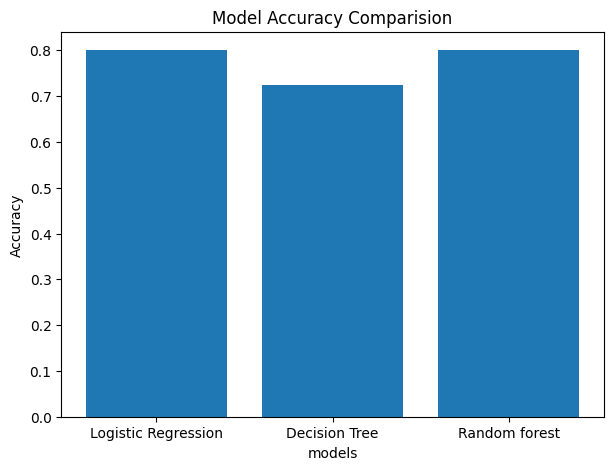

In [74]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random forest']
accuracy= [logistic_accuracy,
            decision_accuracy,
            forest_accuracy]

plt.figure(figsize=(7,5))

plt.bar(models,accuracy)
plt.title("Model Accuracy Comparision")

plt.ylabel('Accuracy')
plt.xlabel('models')
plt.show()

### step 13. Classification report

In [64]:
print("\n Classification Report")

print(classification_report(y_test,forest_pred))


 Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1009
           1       0.68      0.55      0.61       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.79      0.80      0.79      1409



### Step 14. Confusion Matrix

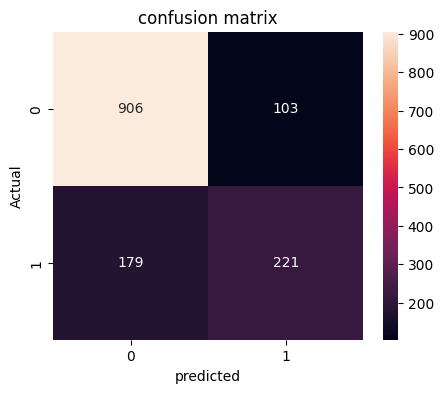

In [68]:
cm = confusion_matrix(y_test, forest_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("Actual")

plt.show()

### step 15. Final Conclusion



In [ ]:
print("\n Project Completed Sucessfully")
print("Customer Churn Prediction using Machine Learning")
print("")